<a href="https://colab.research.google.com/github/sshriish/Password-generator-using-Optimization-techniques/blob/main/Password_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔐 Password Generation using Optimization Algorithms
This notebook lets you generate strong passwords using three AI optimization techniques:
- Genetic Algorithm (GA)
- Ant Colony Optimization (ACO)  
- Particle Swarm Optimization (PSO)

Just click the ▶ play button next to any section to run it!

# 🔐 Password Generation using Optimization Algorithms

This notebook generates strong passwords using 3 AI optimization techniques.
Run each section by clicking the ▶ play button on the left of each code cell.

**No installation needed — just run and see the results!**

In [1]:
import random
import string
import re

LOWERCASE = string.ascii_lowercase
UPPERCASE = string.ascii_uppercase
DIGITS    = string.digits
SYMBOLS   = "!@#$%^&*()_+-=[]{}|;:,.<>?"
ALL_CHARS = LOWERCASE + UPPERCASE + DIGITS + SYMBOLS

PASSWORD_LENGTH = 12

def fitness(password):
    score = 0.0
    length = len(password)

    # Length contribution
    score += min(length * 2.5, 30)

    # Character variety
    has_lower  = bool(re.search(r'[a-z]', password))
    has_upper  = bool(re.search(r'[A-Z]', password))
    has_digit  = bool(re.search(r'[0-9]', password))
    has_symbol = bool(re.search(r'[^a-zA-Z0-9]', password))

    score += sum([has_lower, has_upper, has_digit, has_symbol]) * 10

    # Uniqueness
    unique_ratio = len(set(password)) / max(length, 1)
    score += unique_ratio * 20

    # Penalty for repeated characters
    repeats = sum(1 for i in range(length - 1) if password[i] == password[i+1])
    score -= repeats * 2

    # Penalty for sequential characters (like abc, 123)
    sequentials = sum(
        1 for i in range(length - 2)
        if ord(password[i+1]) - ord(password[i]) == 1
        and ord(password[i+2]) - ord(password[i+1]) == 1
    )
    score -= sequentials * 3

    return max(score, 0.0)


def random_password(length=PASSWORD_LENGTH):
    return ''.join(random.choices(ALL_CHARS, k=length))


# Example usage
pwd = random_password()
print("Generated Password:", pwd)
print("Fitness Score:", fitness(pwd))

print("✅ Setup complete! Now run one of the algorithm cells below.")

Generated Password: }ASC-N.%APbI
Fitness Score: 78.33333333333333
✅ Setup complete! Now run one of the algorithm cells below.


In [2]:
def selection(population, fitnesses, k=3):
    candidates = random.choices(range(len(population)), k=k)
    best = max(candidates, key=lambda i: fitnesses[i])
    return population[best]


def crossover(p1, p2):
    point = random.randint(1, len(p1) - 1)
    return p1[:point] + p2[point:], p2[:point] + p1[point:]


def mutate(password, mutation_rate=0.05):
    pwd = list(password)
    for i in range(len(pwd)):
        if random.random() < mutation_rate:
            pwd[i] = random.choice(ALL_CHARS)
    return ''.join(pwd)


def genetic_algorithm(population_size=100, generations=200, mutation_rate=0.05, elite_size=5):
    population = [random_password() for _ in range(population_size)]

    best_password = ""
    best_fitness_score = -1.0

    for gen in range(generations):
        fitnesses = [fitness(p) for p in population]

        # Find best in current generation
        gen_best_idx = max(range(len(fitnesses)), key=lambda i: fitnesses[i])

        if fitnesses[gen_best_idx] > best_fitness_score:
            best_fitness_score = fitnesses[gen_best_idx]
            best_password = population[gen_best_idx]

        # Progress print
        if gen % 50 == 0 or gen == generations - 1:
            print(f"  Gen {gen:>3}  |  Best fitness: {best_fitness_score:.2f}  |  Password: {best_password}")

        # Sort population by fitness (descending)
        sorted_pop = [p for _, p in sorted(zip(fitnesses, population), reverse=True)]

        # Elitism
        new_population = sorted_pop[:elite_size]

        # Generate new population
        while len(new_population) < population_size:
            p1 = selection(population, fitnesses)
            p2 = selection(population, fitnesses)

            c1, c2 = crossover(p1, p2)

            new_population.append(mutate(c1, mutation_rate))

            if len(new_population) < population_size:
                new_population.append(mutate(c2, mutation_rate))

        population = new_population

    return best_password, best_fitness_score


# Run the algorithm
print("=" * 55)
print(" 🧬 Genetic Algorithm — Secure Password Generation")
print("=" * 55)

ga_password, ga_score = genetic_algorithm()

# Compare with random passwords
random_scores_ga = [fitness(random_password()) for _ in range(10)]

print(f"\n✅ Best GA password : {ga_password}")
print(f"   Fitness score    : {ga_score:.2f}")
print(f"   Avg random score : {sum(random_scores_ga)/len(random_scores_ga):.2f}")

 🧬 Genetic Algorithm — Secure Password Generation
  Gen   0  |  Best fitness: 90.00  |  Password: #ny<{5|xH.Ib
  Gen  50  |  Best fitness: 90.00  |  Password: #ny<{5|xH.Ib
  Gen 100  |  Best fitness: 90.00  |  Password: #ny<{5|xH.Ib
  Gen 150  |  Best fitness: 90.00  |  Password: #ny<{5|xH.Ib
  Gen 199  |  Best fitness: 90.00  |  Password: #ny<{5|xH.Ib

✅ Best GA password : #ny<{5|xH.Ib
   Fitness score    : 90.00
   Avg random score : 88.17


In [3]:
import numpy as np

def ant_colony(n_ants=50, n_iterations=100, alpha=1.0, beta=2.0, evaporation=0.5, Q=100.0):
    charset = list(ALL_CHARS)
    n_chars = len(charset)

    # Heuristic: prefer symbols, digits, uppercase
    heuristic = np.array([
        2.0 if c in SYMBOLS else
        1.5 if c in DIGITS else
        1.2 if c in UPPERCASE else
        1.0
        for c in charset
    ])

    # Initialize pheromone
    pheromone = np.ones((PASSWORD_LENGTH, n_chars))

    best_password = ""
    best_fitness_score = -1.0

    for iteration in range(n_iterations):
        passwords = []

        # Generate solutions (ants)
        for _ in range(n_ants):
            password = []

            for pos in range(PASSWORD_LENGTH):
                prob = (pheromone[pos] ** alpha) * (heuristic ** beta)
                prob /= prob.sum()

                char_idx = np.random.choice(n_chars, p=prob)
                password.append(charset[char_idx])

            passwords.append(''.join(password))

        # Evaluate
        fitnesses = [fitness(p) for p in passwords]

        # Evaporation
        pheromone *= (1 - evaporation)

        # Update pheromone
        for p, f in zip(passwords, fitnesses):
            for pos, char in enumerate(p):
                idx = charset.index(char)
                pheromone[pos][idx] += Q * f / 100

        # Best solution update
        gen_best = max(zip(passwords, fitnesses), key=lambda x: x[1])

        if gen_best[1] > best_fitness_score:
            best_fitness_score = gen_best[1]
            best_password = gen_best[0]

        # Progress
        if iteration % 25 == 0 or iteration == n_iterations - 1:
            print(f"  Iter {iteration:>3}  |  Best fitness: {best_fitness_score:.2f}  |  Password: {best_password}")

    return best_password, best_fitness_score


# Run ACO
print("=" * 55)
print(" 🐜 Ant Colony Optimization — Password Generation")
print("=" * 55)

aco_password, aco_score = ant_colony()

# Compare with random
random_scores_aco = [fitness(random_password()) for _ in range(10)]

print(f"\n✅ Best ACO password : {aco_password}")
print(f"   Fitness score     : {aco_score:.2f}")
print(f"   Avg random score  : {sum(random_scores_aco)/len(random_scores_aco):.2f}")

 🐜 Ant Colony Optimization — Password Generation
  Iter   0  |  Best fitness: 90.00  |  Password: ^@7$*=meZ_!S
  Iter  25  |  Best fitness: 90.00  |  Password: ^@7$*=meZ_!S
  Iter  50  |  Best fitness: 90.00  |  Password: ^@7$*=meZ_!S
  Iter  75  |  Best fitness: 90.00  |  Password: ^@7$*=meZ_!S
  Iter  99  |  Best fitness: 90.00  |  Password: ^@7$*=meZ_!S

✅ Best ACO password : ^@7$*=meZ_!S
   Fitness score     : 90.00
   Avg random score  : 83.47


In [4]:
def particle_swarm(n_particles=60, n_iterations=150, inertia=0.7, c1=1.5, c2=1.5, w_decay=0.99):
    charset = list(ALL_CHARS)
    n_chars = len(charset)

    # Initialize particles
    positions = np.random.randint(0, n_chars, (n_particles, PASSWORD_LENGTH))
    velocities = np.zeros((n_particles, PASSWORD_LENGTH))

    # Personal best
    pbest_pos = positions.copy()
    pbest_scores = np.array([
        fitness(''.join(charset[i] for i in pos)) for pos in positions
    ])

    # Global best
    gbest_idx = np.argmax(pbest_scores)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_score = pbest_scores[gbest_idx]
    best_password = ''.join(charset[i] for i in gbest_pos)

    for iteration in range(n_iterations):
        # Update inertia (decay)
        inertia *= w_decay

        # Random coefficients
        r1 = np.random.rand(n_particles, PASSWORD_LENGTH)
        r2 = np.random.rand(n_particles, PASSWORD_LENGTH)

        # Velocity update
        velocities = (
            inertia * velocities
            + c1 * r1 * (pbest_pos - positions)
            + c2 * r2 * (gbest_pos - positions)
        )

        # Position update (discrete mapping)
        positions = (positions + np.round(velocities).astype(int)) % n_chars

        # Evaluate
        scores = np.array([
            fitness(''.join(charset[i] for i in pos)) for pos in positions
        ])

        # Update personal best
        improved = scores > pbest_scores
        pbest_pos[improved] = positions[improved]
        pbest_scores[improved] = scores[improved]

        # Update global best
        best_idx = np.argmax(pbest_scores)
        if pbest_scores[best_idx] > gbest_score:
            gbest_score = pbest_scores[best_idx]
            gbest_pos = pbest_pos[best_idx].copy()
            best_password = ''.join(charset[i] for i in gbest_pos)

        # Progress
        if iteration % 30 == 0 or iteration == n_iterations - 1:
            print(f"  Iter {iteration:>3}  |  Best fitness: {gbest_score:.2f}  |  Password: {best_password}")

    return best_password, gbest_score


# Run PSO
print("=" * 55)
print(" 🌀 Particle Swarm Optimization — Password Generation")
print("=" * 55)

pso_password, pso_score = particle_swarm()

# Compare with random
random_scores_pso = [fitness(random_password()) for _ in range(10)]

print(f"\n✅ Best PSO password : {pso_password}")
print(f"   Fitness score     : {pso_score:.2f}")
print(f"   Avg random score  : {sum(random_scores_pso)/len(random_scores_pso):.2f}")

 🌀 Particle Swarm Optimization — Password Generation
  Iter   0  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@
  Iter  30  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@
  Iter  60  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@
  Iter  90  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@
  Iter 120  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@
  Iter 149  |  Best fitness: 90.00  |  Password: u0oUv]1HX,F@

✅ Best PSO password : u0oUv]1HX,F@
   Fitness score     : 90.00
   Avg random score  : 83.97


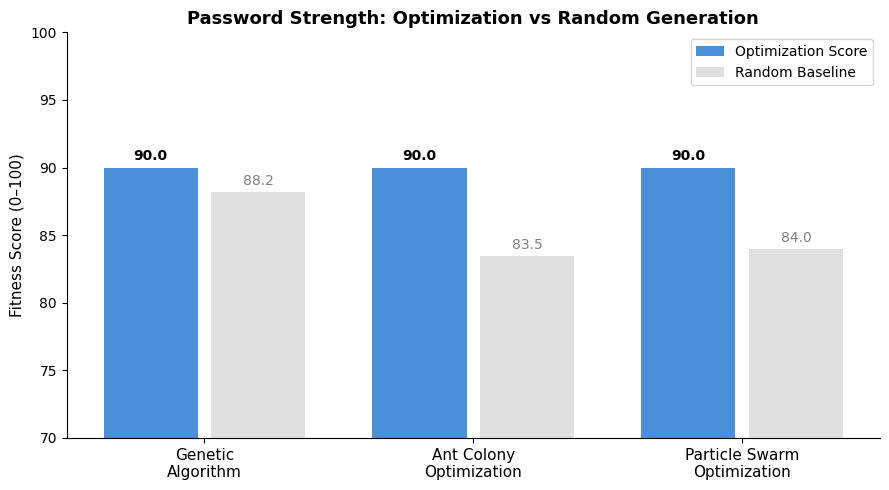


📊 Results Summary
----------------------------------------------------
Algorithm                    Password         Score
----------------------------------------------------
Genetic Algorithm            #ny<{5|xH.Ib     90.00
Ant Colony Optim.            ^@7$*=meZ_!S     90.00
Particle Swarm               u0oUv]1HX,F@     90.00
----------------------------------------------------

🏆 Best password overall: #ny<{5|xH.Ib


In [5]:
import matplotlib.pyplot as plt

algorithms  = ['Genetic\nAlgorithm', 'Ant Colony\nOptimization', 'Particle Swarm\nOptimization']
scores      = [ga_score, aco_score, pso_score]
passwords   = [ga_password, aco_password, pso_password]

avg_randoms = [
    sum(random_scores_ga)  / len(random_scores_ga),
    sum(random_scores_aco) / len(random_scores_aco),
    sum(random_scores_pso) / len(random_scores_pso),
]

x = range(len(algorithms))

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar([i - 0.2 for i in x], scores, width=0.35,
               label='Optimization Score', color='#4A90D9')

bars2 = ax.bar([i + 0.2 for i in x], avg_randoms, width=0.35,
               label='Random Baseline', color='#E0E0E0')

# Labels and styling
ax.set_xticks(list(x))
ax.set_xticklabels(algorithms, fontsize=11)
ax.set_ylabel('Fitness Score (0–100)', fontsize=11)
ax.set_title('Password Strength: Optimization vs Random Generation',
             fontsize=13, fontweight='bold')

ax.set_ylim(70, 100)
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, score in zip(bars1, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{score:.1f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

for bar, score in zip(bars2, avg_randoms):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{score:.1f}',
            ha='center', va='bottom',
            fontsize=10, color='gray')

plt.tight_layout()
plt.show()


# Summary table
print("\n📊 Results Summary")
print("-" * 52)
print(f"{'Algorithm':<28} {'Password':<15} {'Score':>6}")
print("-" * 52)

for algo, pwd, sc in zip(
    ['Genetic Algorithm', 'Ant Colony Optim.', 'Particle Swarm'],
    passwords,
    scores
):
    print(f"{algo:<28} {pwd:<15} {sc:>6.2f}")

print("-" * 52)

print(f"\n🏆 Best password overall: {passwords[scores.index(max(scores))]}")